# Mistral OCR-4 — Nvidia 10-Q Form Analysis

This notebook applies Mistral OCR-4 to the **Nvidia 10-Q SEC Filing** and demonstrates five table-handling and output capabilities:

| # | Feature | Parameter |
|---|---------|---|
| 1 | **Markdown Output** | Default response `.markdown` field |
| 2 | **Page-6 Table Handling** | Fifth option: normalize empty cells before DataFrame conversion |
| 3 | **Paragraph-Level Bounding Boxes** | `include_blocks: true` — `text` / `title` / `list` block types |
| 4 | **Regional-Level Confidence** | `confidence_scores_granularity: 'page'` |
| 5 | **Bounding Box Classification** | `include_blocks: true` — all 13 semantic block types |

> **Document**: `samples/Nvidia-10-Q-Form.pdf` (pages 1–30 of 45; API limit is 30 pages)  
> **Model**: `mistral-ocr-4-0` via Azure AI Foundry

---
## 0. Setup

In [5]:

import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import warnings
from IPython.display import Markdown, display
from dotenv import load_dotenv
from ocr4_utils import OCRConfig
from ocr4_utils import (
    BLOCK_COLORS,
    PARAGRAPH_TYPES,
    blocks_to_dataframe,
    encode_file,
    ocr_request,
)
from ocr4_utils import markdown_table_to_df

warnings.filterwarnings('ignore')
print('Libraries loaded successfully')

Libraries loaded successfully


In [4]:

config = OCRConfig.from_env()
ENDPOINT = config.endpoint
API_KEY = config.api_key
MODEL_NAME = config.model_name
HEADERS = config.headers
SAMPLES_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'samples')
NVIDIA_PDF = os.path.join(SAMPLES_DIR, 'Nvidia-10-Q-Form-p1-30.pdf')

print(f'Model    : {MODEL_NAME}')

Model    : mistral-ocr-4-0


---
## 1. OCR-4 API Call

Single request that enables all four features simultaneously:
- `include_blocks: true` → bounding boxes + block classification
- `confidence_scores_granularity: 'page'` → per-page (regional) confidence
- `extract_header / extract_footer: true` → captures document headers/footers
- `table_format: 'markdown'` → tables rendered as markdown

In [4]:
payload = {
    'model': MODEL_NAME,
    'document': {
        'type': 'document_url',
        'document_url': f'data:application/pdf;base64,{encode_file(NVIDIA_PDF)}',
    },
    'include_blocks': True,
    'confidence_scores_granularity': 'page',
    'extract_header': True,
    'extract_footer': True,
    'table_format': 'markdown',
}

response   = ocr_request(payload)
pages      = response['pages']
n_pages    = len(pages)

print(f'Model           : {response["model"]}')
print(f'Pages processed : {n_pages}')
print(f'Usage           : {response.get("usage", {})}')


Model           : mistral-ocr-4-0
Pages processed : 30
Usage           : {}


---
## 2. Markdown Output

OCR-4 converts the entire PDF into clean markdown, preserving:
- Heading hierarchy (`#`, `##`, `###`)
- Tables (rendered per `table_format`)
- Lists, bold/italic emphasis
- Mathematical expressions (LaTeX `$…$`)
- Image references (`![…](…)`)

In [5]:
# ── 2a. Per-page markdown statistics ────────────────────────────────────────

md_stats = []
for p in pages:
    md = p.get('markdown') or ''
    lines  = md.splitlines()
    tables = sum(1 for l in lines if l.strip().startswith('|'))
    headings = sum(1 for l in lines if l.startswith('#'))
    md_stats.append({
        'Page':          p['index'] + 1,
        'Chars':         len(md),
        'Lines':         len(lines),
        'Headings':      headings,
        'Table lines':   tables,
    })

df_md = pd.DataFrame(md_stats).set_index('Page')
display(df_md)

total_chars = df_md['Chars'].sum()
print(f'\nTotal markdown characters : {total_chars:,}')

,Chars,Lines,Headings,Table lines
Page,,,,
1,2473,59,2,0
2,1407,29,3,0
3,334,12,3,0
4,240,8,1,0
5,212,8,1,0
6,219,7,1,0
7,222,8,1,0
8,3750,37,10,0
9,1094,27,3,0



Total markdown characters : 67,088


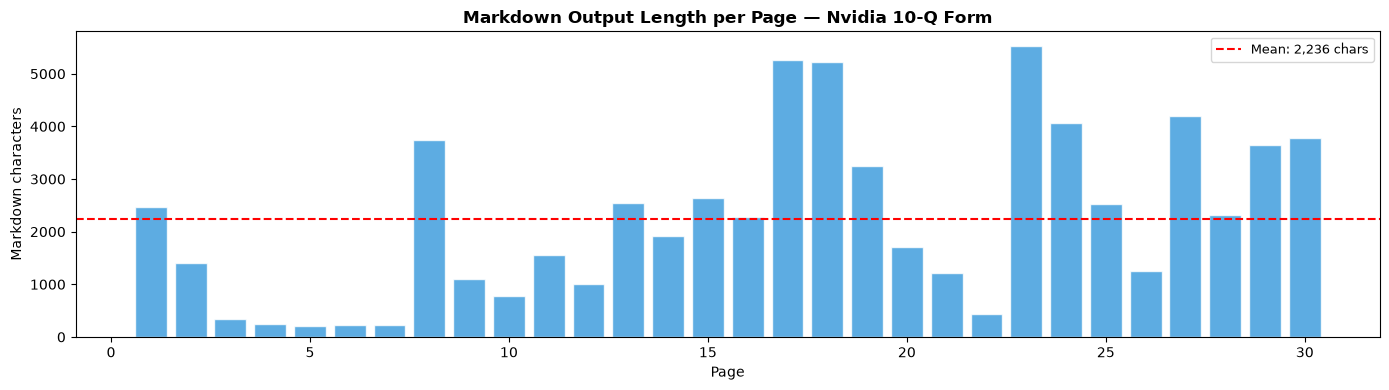

In [6]:
# ── 2b. Character count per page (document density) ─────────────────────────

fig, ax = plt.subplots(figsize=(14, 4))
page_nums = df_md.index.tolist()
chars     = df_md['Chars'].tolist()
bars = ax.bar(page_nums, chars, color='#3498DB', alpha=0.8, edgecolor='white')
ax.set_xlabel('Page')
ax.set_ylabel('Markdown characters')
ax.set_title('Markdown Output Length per Page — Nvidia 10-Q Form', fontweight='bold')
ax.axhline(y=np.mean(chars), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {int(np.mean(chars)):,} chars')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# ── 2ca. Rendered markdown preview: first 1 500 characters of page 1 ──────────

page1_md = pages[0].get('markdown', '')
display(Markdown(f'### Page 1 — Markdown Preview\n\n{page1_md[:1500]}\n\n*(truncated)*'))

### Page 1 — Markdown Preview

# FORM 10-Q

☒ QUARTERLY REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934

For the quarterly period ended April 26, 2026

OR

☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934

Commission File Number: 0-23985

# NVIDIA CORPORATION

(Exact name of registrant as specified in its charter)

Delaware

(State or other jurisdiction of
incorporation or organization)

94-3177549

(I.R.S. Employer
Identification No.)

2788 San Tomas Expressway, Santa Clara, California

(Address of principal executive offices)

95051

(Zip Code)

(408) 486-2000

(Registrant's telephone number, including area code)

N/A

(Former name, former address and former fiscal year, if changed since last report)

Securities registered pursuant to Section 12(b) of the Act:

[tbl-0.md](tbl-0.md)

Indicate by check mark whether the registrant (1) has filed all reports required to be filed by Section 13 or 15(d) of the Securities Exchange Act of 1934 during the preceding 12 months (or for such shorter period that the registrant was required to file such reports), and (2) has been subject to such filing requirements for the past 90 days. Yes ☒ No ☐

Indicate by check mark whether the registrant has submitted electronically every Interactive Data File required to be submitted pursuant to Rule 405 of Regulation S-T (§232.405 of this chapter) during the preceding 12 months (or for such shorter period that the registrant was required to submit such files

*(truncated)*

In [8]:
# ── 2d. Export full markdown to file ────────────────────────────────────────

full_md = '\n\n---\n\n'.join(
    f'<!-- Page {p["index"] + 1} -->\n{p.get("markdown", "")}'
    for p in pages
)

output_md_path = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                               'nvidia_10q_ocr4_output.md')
with open(output_md_path, 'w', encoding='utf-8') as f:
    f.write(full_md)

print(f'Full markdown saved to: {output_md_path}')
print(f'File size             : {os.path.getsize(output_md_path):,} bytes')

Full markdown saved to: /Users/peymanmohajerian/Documents/tech/microsoft/cook-book/microsoft/ocr4-doc-ai/nvidia_10q_ocr4_output.md
File size             : 67,834 bytes


### 2e. Fifth option: page-6 table handling with empty cells preserved

When OCR tables contain blank cells, the main risk is that a missing value shifts the remaining columns to the left. The safest approach is to pad short rows before building a DataFrame so blanks stay in place and do not corrupt the result.

This example uses the table on page 6 of the Nvidia 10-Q and shows that empty cells are treated as missing values, not as data that moves neighboring columns.

In [ ]:
# ── 2e. Fifth table-handling option: page 6, empty cells preserved ────────
page6 = next((page for page in pages if page.get('index') == 5), pages[5])
page6_table_md = next(
    (
        (table.get('content') or '').strip()
        for table in page6.get('tables', [])
        if (table.get('content') or '').strip()
    ),
    '',
)

if page6_table_md:
    page6_df = markdown_table_to_df(page6_table_md)
    display(Markdown('### Page 6 — empty-cell-safe table parsing'))
    display(page6_df.head(10))
    print(f'\nParsed rows: {len(page6_df)}')
    print('Blank cells preserved as missing values:')
    print(page6_df.isna().sum().to_dict())
    print('\nColumns remain aligned after padding short rows:')
    display(page6_df.fillna('').astype(str).replace('nan', ''))
else:
    print('No table content was returned for page 6.')

### Page 6 — empty-cell-safe table parsing

,,Common Stock Outstanding,,Additional Paid-in Capital,Accumulated Other Comprehensive Income,Retained Earnings,Total Shareholders' Equity
0,"(In millions, except per share data)",Shares,Amount,<NA>,<NA>,<NA>,<NA>
1,"Balances as of Jan 25, 2026","24,304",$ 24,"$ 10,118",$ 178,"$ 146,973","$ 157,293"
2,Net income,—,—,—,—,"58,321","58,321"
3,Other comprehensive loss,—,—,—,(41),—,(41)
4,Issuance of common stock,37,—,515,—,—,515
5,Tax withholding related to common stock,(12),—,"(2,129)",—,—,"(2,129)"
6,Shares repurchased,(108),—,(157),—,"(20,013)","(20,170)"
7,Cash dividends declared and paid ($0.01 per co...,—,—,—,—,(243),(243)
8,Stock-based compensation,—,—,"1,928",—,—,"1,928"
9,"Balances as of Apr 26, 2026","24,221",$ 24,"$ 10,275",$ 137,"$ 185,038","$ 195,474"



Parsed rows: 20
Blank cells preserved as missing values:
{'': 0, 'Common Stock Outstanding': 0, 'Additional Paid-in Capital': 1, 'Accumulated Other Comprehensive Income': 1, 'Retained Earnings': 1, "Total Shareholders' Equity": 1}

Columns remain aligned after padding short rows:


,,Common Stock Outstanding,,Additional Paid-in Capital,Accumulated Other Comprehensive Income,Retained Earnings,Total Shareholders' Equity
0,"(In millions, except per share data)",Shares,Amount,,,,
1,"Balances as of Jan 25, 2026","24,304",$ 24,"$ 10,118",$ 178,"$ 146,973","$ 157,293"
2,Net income,—,—,—,—,"58,321","58,321"
3,Other comprehensive loss,—,—,—,(41),—,(41)
4,Issuance of common stock,37,—,515,—,—,515
5,Tax withholding related to common stock,(12),—,"(2,129)",—,—,"(2,129)"
6,Shares repurchased,(108),—,(157),—,"(20,013)","(20,170)"
7,Cash dividends declared and paid ($0.01 per co...,—,—,—,—,(243),(243)
8,Stock-based compensation,—,—,"1,928",—,—,"1,928"
9,"Balances as of Apr 26, 2026","24,221",$ 24,"$ 10,275",$ 137,"$ 185,038","$ 195,474"


---
## 3. Paragraph-Level Bounding Boxes

OCR-4 returns pixel coordinates for each detected block.  
**Paragraph-level blocks** include: `text`, `title`, `list`, `aside_text`, `caption`, `references`.

Each paragraph block carries:
```
top_left_x / top_left_y         (origin corner, pixels)
bottom_right_x / bottom_right_y (opposite corner, pixels)
type                             (semantic classification)
content                          (extracted text in markdown)
```

In [10]:
# ── 3a. Collect all paragraph-level blocks across the document ───────────────

para_rows = []
for p in pages:
    dims = p.get('dimensions') or {}
    for b in (p.get('blocks') or []):
        if b['type'] in PARAGRAPH_TYPES:
            w = b['bottom_right_x'] - b['top_left_x']
            h = b['bottom_right_y'] - b['top_left_y']
            para_rows.append({
                'page':        p['index'] + 1,
                'type':        b['type'],
                'x1':          b['top_left_x'],
                'y1':          b['top_left_y'],
                'x2':          b['bottom_right_x'],
                'y2':          b['bottom_right_y'],
                'width_px':    w,
                'height_px':   h,
                'area_px2':    w * h,
                'page_width':  dims.get('width', 0),
                'page_height': dims.get('height', 0),
                'content':     b['content'],
            })

df_para = pd.DataFrame(para_rows)
print(f'Total paragraph-level blocks : {len(df_para)}')
print(f'Across pages                 : {df_para["page"].nunique()} / {n_pages}')
print()
print(df_para['type'].value_counts().to_string())

Total paragraph-level blocks : 306
Across pages                 : 30 / 30

type
text     210
title     87
list       9


In [11]:
# ── 3b. Paragraph bounding box table (first 20 rows) ─────────────────────────

df_display = df_para[['page', 'type', 'x1', 'y1', 'x2', 'y2',
                        'width_px', 'height_px', 'area_px2']].copy()
df_display['content_preview'] = df_para['content'].str[:60].str.replace('\n', ' ') + '…'
display(df_display.head(20))

,page,type,x1,y1,x2,y2,width_px,height_px,area_px2,content_preview
0,1,title,349,101,437,117,88,16,1408,# FORM 10-Q…
1,1,text,39,120,546,134,507,14,7098,☒ QUARTERLY REPORT PURSUANT TO SECTION 13 OR 1...
2,1,text,61,140,263,154,202,14,2828,"For the quarterly period ended April 26, 2026…"
3,1,text,384,152,403,164,19,12,228,OR…
4,1,text,39,164,546,177,507,13,6591,☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR ...
5,1,text,324,181,462,193,138,12,1656,Commission File Number: 0-23985…
6,1,title,307,269,479,287,172,18,3096,# NVIDIA CORPORATION…
7,1,text,291,287,496,298,205,11,2255,(Exact name of registrant as specified in its ...
8,1,text,194,299,240,310,46,11,506,Delaware…
9,1,text,148,312,286,337,138,25,3450,(State or other jurisdiction of incorporation ...


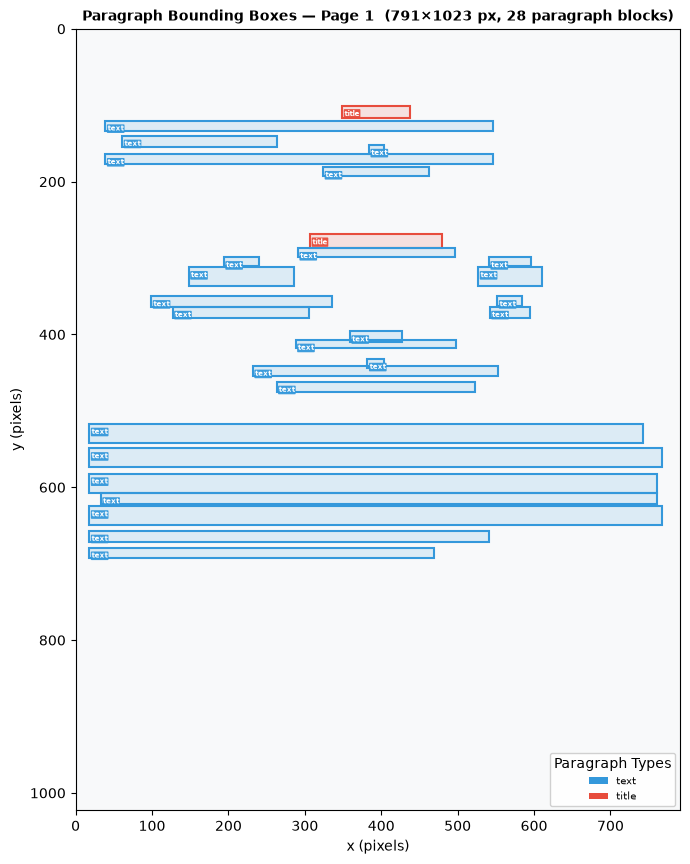

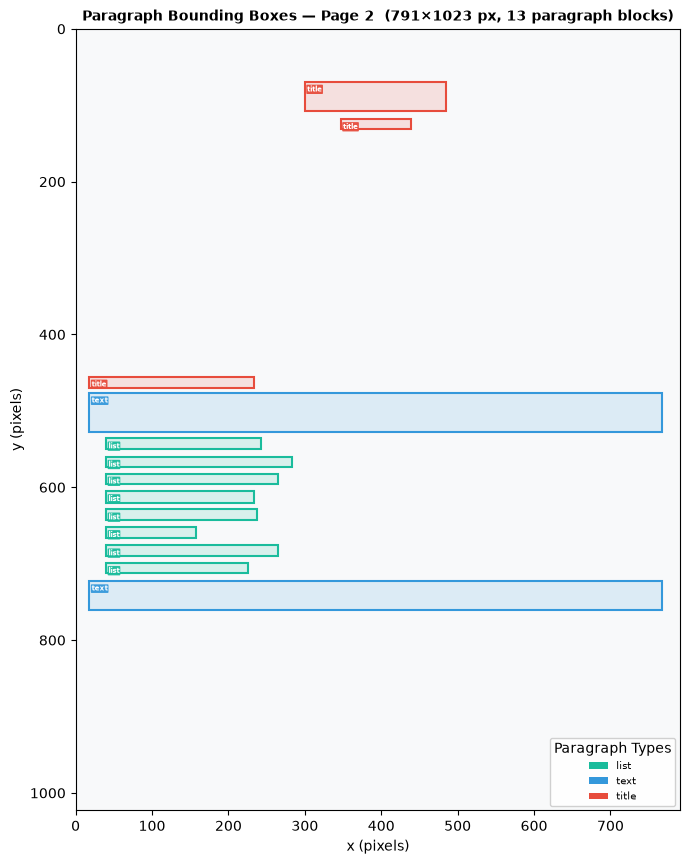

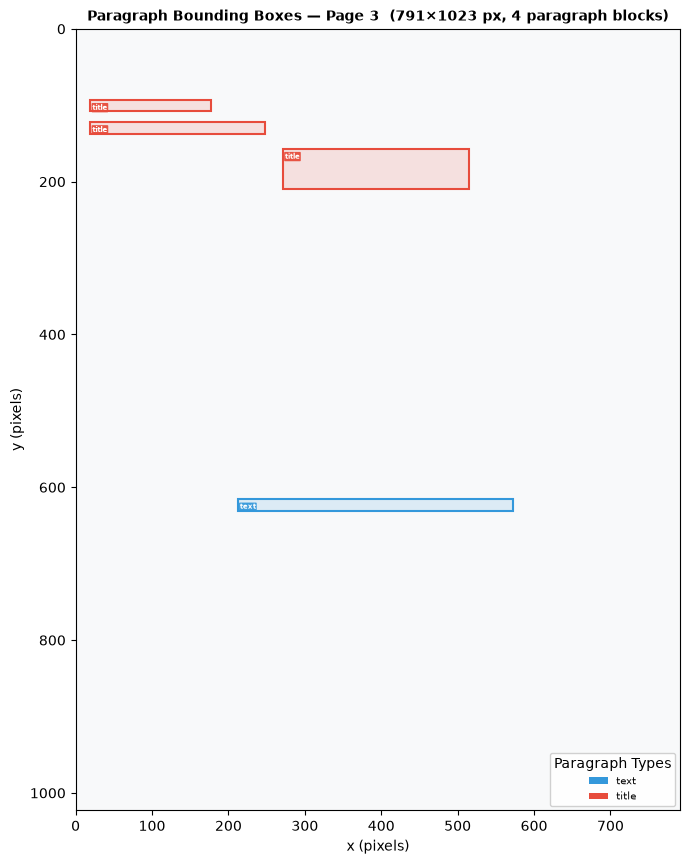

In [12]:
# ── 3c. Paragraph bounding box overlay on the first three pages ──────────────

def render_paragraph_boxes(page_data: dict, para_types: set, title: str = '') -> None:
    """Render paragraph-level blocks as annotated rectangles on a white canvas."""
    dims   = page_data.get('dimensions') or {}
    width  = dims.get('width',  612)
    height = dims.get('height', 792)
    blocks = [b for b in (page_data.get('blocks') or []) if b['type'] in para_types]

    fig, ax = plt.subplots(figsize=(7, 10))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_facecolor('#F8F9FA')
    ax.set_aspect('equal')

    seen_types = set()
    for idx, b in enumerate(blocks):
        x1, y1 = b['top_left_x'], b['top_left_y']
        x2, y2 = b['bottom_right_x'], b['bottom_right_y']
        btype  = b['type']
        color  = BLOCK_COLORS.get(btype, '#888888')
        w, h   = x2 - x1, y2 - y1

        ax.add_patch(patches.Rectangle(
            (x1, y1), w, h,
            linewidth=0, facecolor=color, alpha=0.14
        ))
        ax.add_patch(patches.Rectangle(
            (x1, y1), w, h,
            linewidth=1.5, edgecolor=color, facecolor='none'
        ))
        ax.text(
            x1 + 3, y1 + 13, btype,
            fontsize=5, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.12', facecolor=color,
                      alpha=0.95, edgecolor='none'),
        )
        seen_types.add(btype)

    legend_handles = [
        patches.Patch(facecolor=BLOCK_COLORS.get(t, '#888'), label=t)
        for t in sorted(seen_types)
    ]
    ax.legend(handles=legend_handles, loc='lower right',
              fontsize=7, framealpha=0.9, title='Paragraph Types')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
    plt.tight_layout()
    plt.show()


# Show first 3 pages
for page_obj in pages[:3]:
    pg_num = page_obj['index'] + 1
    dims   = page_obj.get('dimensions') or {}
    n_para = sum(1 for b in (page_obj.get('blocks') or [])
                 if b['type'] in PARAGRAPH_TYPES)
    render_paragraph_boxes(
        page_obj,
        para_types=PARAGRAPH_TYPES,
        title=f'Paragraph Bounding Boxes — Page {pg_num}  '
              f'({dims.get("width", "?")}×{dims.get("height", "?")} px, '
              f'{n_para} paragraph blocks)',
    )

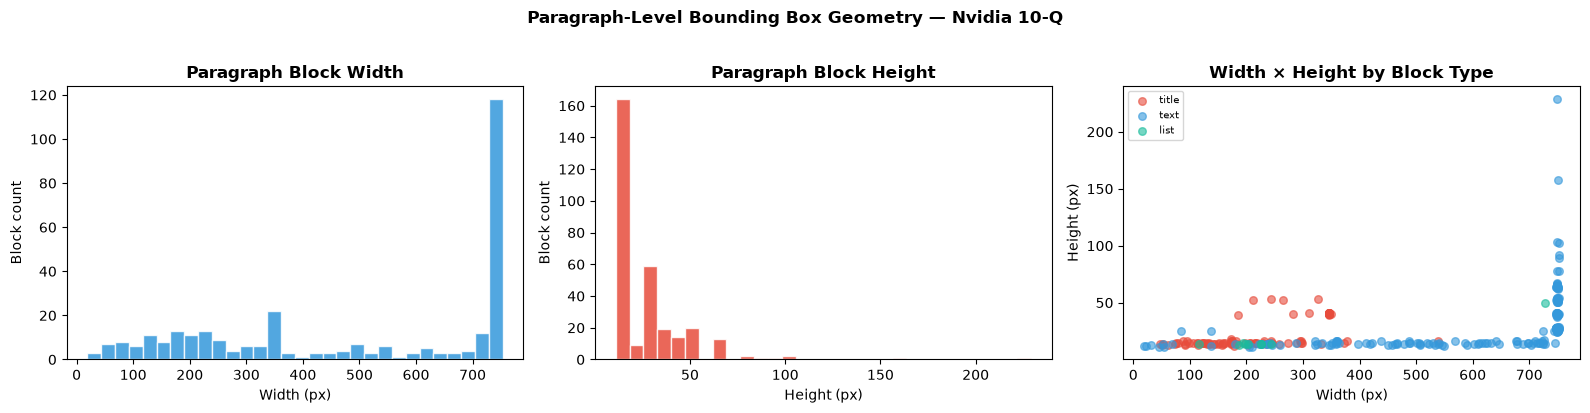

In [13]:
# ── 3d. Paragraph block size distribution ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Width distribution
axes[0].hist(df_para['width_px'], bins=30, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Block count')
axes[0].set_title('Paragraph Block Width', fontweight='bold')

# Height distribution
axes[1].hist(df_para['height_px'], bins=30, color='#E74C3C', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Block count')
axes[1].set_title('Paragraph Block Height', fontweight='bold')

# Area scatter by type
for btype in df_para['type'].unique():
    subset = df_para[df_para['type'] == btype]
    axes[2].scatter(subset['width_px'], subset['height_px'],
                    label=btype, color=BLOCK_COLORS.get(btype, '#888'),
                    alpha=0.6, s=30)
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')
axes[2].set_title('Width × Height by Block Type', fontweight='bold')
axes[2].legend(fontsize=7)

plt.suptitle('Paragraph-Level Bounding Box Geometry — Nvidia 10-Q',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

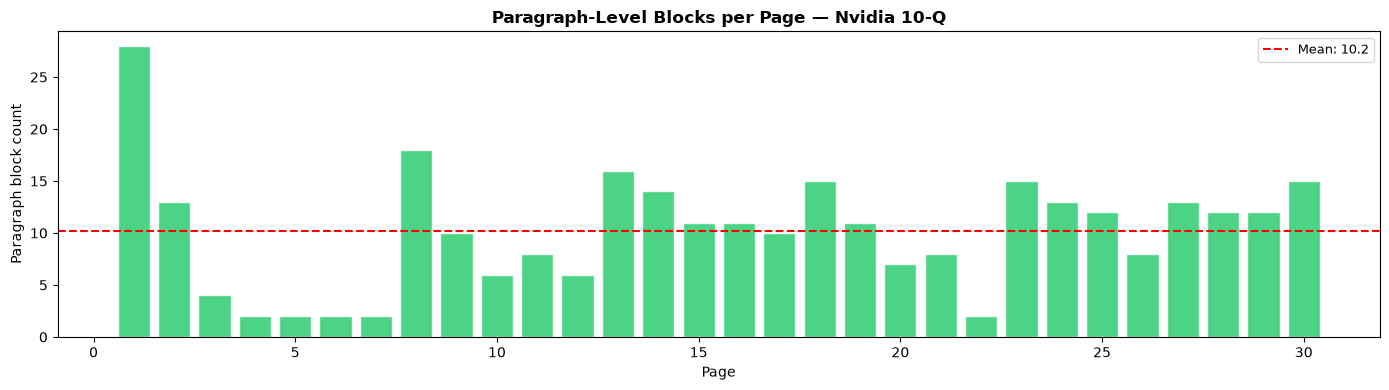

In [14]:
# ── 3e. Paragraph blocks per page ────────────────────────────────────────────

para_per_page = df_para.groupby('page').size().reindex(range(1, n_pages + 1), fill_value=0)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(para_per_page.index, para_per_page.values,
       color='#2ECC71', alpha=0.85, edgecolor='white')
ax.set_xlabel('Page')
ax.set_ylabel('Paragraph block count')
ax.set_title('Paragraph-Level Blocks per Page — Nvidia 10-Q', fontweight='bold')
ax.axhline(y=para_per_page.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {para_per_page.mean():.1f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Regional-Level Confidence

With `confidence_scores_granularity: 'page'`, OCR-4 returns per-page (regional) confidence metrics:

| Field | Description |
|-------|-------------|
| `average_page_confidence_score` | Mean confidence across all tokens on the page |
| `minimum_page_confidence_score` | Lowest single-token confidence — flags problematic regions |

Scores range **0 → 1**. Pages below ~0.85 may contain low-resolution regions, unusual fonts, or complex layouts.

In [15]:
# ── 4a. Extract per-page confidence scores ────────────────────────────────────

conf_rows = []
for p in pages:
    cs = p.get('confidence_scores') or {}
    avg = cs.get('average_page_confidence_score')
    mn  = cs.get('minimum_page_confidence_score')
    conf_rows.append({
        'page':    p['index'] + 1,
        'avg':     avg,
        'minimum': mn,
        'range':   (avg - mn) if (avg is not None and mn is not None) else None,
    })

df_conf = pd.DataFrame(conf_rows).set_index('page')

print('Regional (page-level) confidence scores:')
print()
display(df_conf.style.format({
    'avg':     '{:.4f}',
    'minimum': '{:.4f}',
    'range':   '{:.4f}',
}).background_gradient(subset=['avg'], cmap='RdYlGn', vmin=0.8, vmax=1.0))

Regional (page-level) confidence scores:



,avg,minimum,range
page,,,
1,0.9795,0.2791,0.7004
2,0.9852,0.2645,0.7208
3,0.9916,0.3757,0.6159
4,0.9798,0.3537,0.6261
5,0.9925,0.3357,0.6568
6,0.9950,0.3969,0.5981
7,0.9940,0.3678,0.6262
8,0.9855,0.3947,0.5908
9,0.9879,0.3434,0.6445


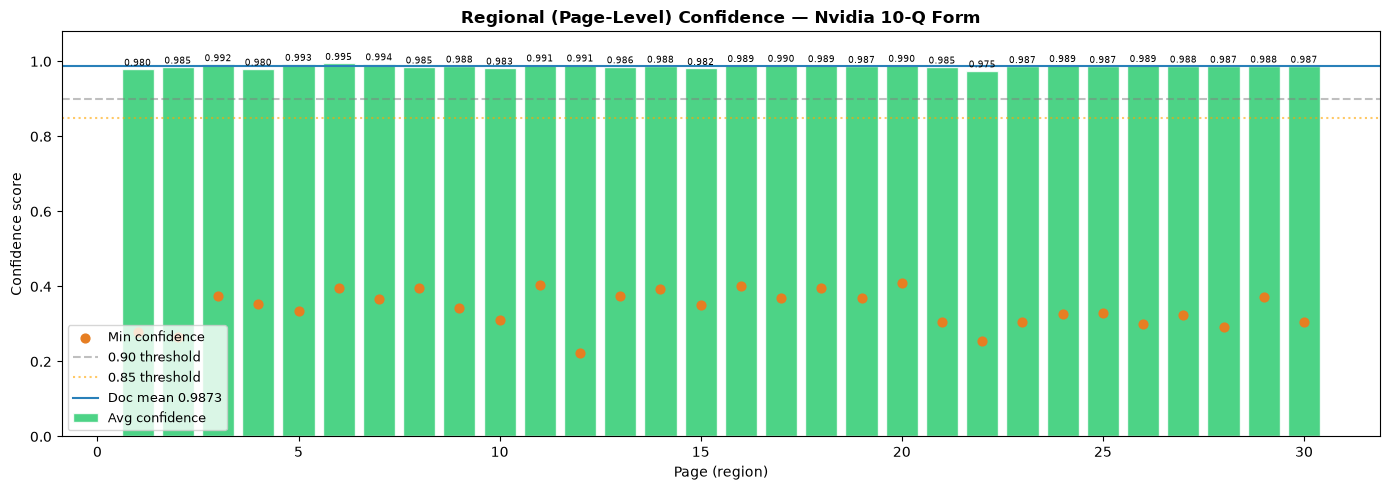

In [16]:
# ── 4b. Per-page confidence bar chart ────────────────────────────────────────

valid = df_conf.dropna(subset=['avg'])

fig, ax = plt.subplots(figsize=(14, 5))

bar_colors = ['#E74C3C' if v < 0.85 else '#2ECC71' for v in valid['avg']]
bars = ax.bar(valid.index, valid['avg'], color=bar_colors, alpha=0.85,
               edgecolor='white', label='Avg confidence')

# Plot minimum as scatter overlay
ax.scatter(valid.index, valid['minimum'], color='#E67E22', zorder=5,
           s=40, label='Min confidence')

ax.axhline(y=0.90, color='gray',    linestyle='--', alpha=0.5, label='0.90 threshold')
ax.axhline(y=0.85, color='orange',  linestyle=':',  alpha=0.6, label='0.85 threshold')
ax.axhline(y=valid['avg'].mean(), color='#2980B9', linestyle='-', linewidth=1.5,
           label=f'Doc mean {valid["avg"].mean():.4f}')

ax.set_ylim(0, 1.08)
ax.set_xlabel('Page (region)')
ax.set_ylabel('Confidence score')
ax.set_title('Regional (Page-Level) Confidence — Nvidia 10-Q Form', fontweight='bold')
ax.legend(fontsize=9, loc='lower left')

for bar, val in zip(bars, valid['avg']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=6.5)

plt.tight_layout()
plt.show()

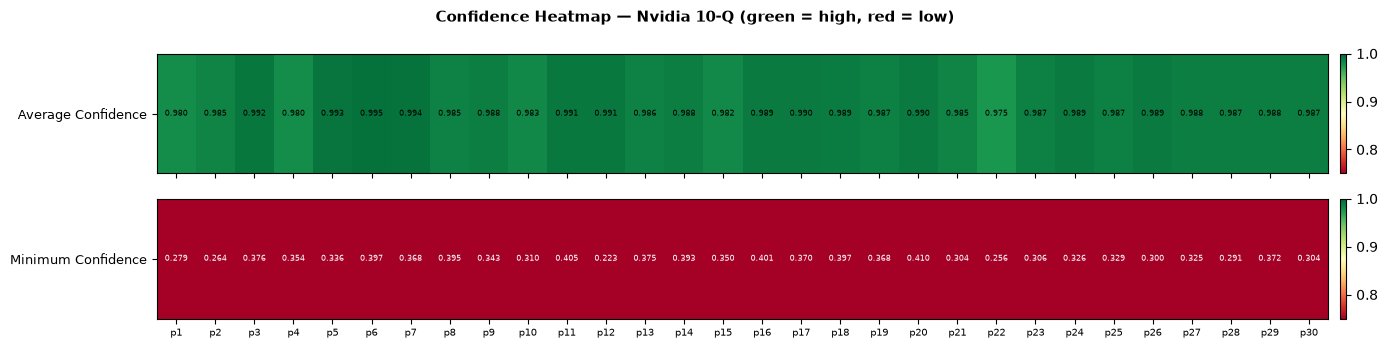

In [17]:
# ── 4c. Confidence heatmap strip (avg vs minimum per page) ───────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 3.5), sharex=True)

for ax, col, label, cmap in zip(
    axes,
    ['avg', 'minimum'],
    ['Average Confidence', 'Minimum Confidence'],
    ['RdYlGn', 'RdYlGn'],
):
    vals = valid[col].values.reshape(1, -1)
    im = ax.imshow(vals, aspect='auto', cmap=cmap, vmin=0.75, vmax=1.0)
    ax.set_yticks([0])
    ax.set_yticklabels([label], fontsize=9)
    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels([f'p{i}' for i in valid.index], fontsize=7)
    plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.015, pad=0.01)
    for j, v in enumerate(vals[0]):
        ax.text(j, 0, f'{v:.3f}', ha='center', va='center', fontsize=6,
                color='black' if v > 0.85 else 'white')

plt.suptitle('Confidence Heatmap — Nvidia 10-Q (green = high, red = low)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ── 4d. Confidence summary statistics ────────────────────────────────────────

avg_scores = valid['avg'].dropna()
min_scores = valid['minimum'].dropna()

summary = pd.DataFrame({
    'Metric':         ['Document mean', 'Document min', 'Document max',
                       'Pages ≥ 0.90',  'Pages ≥ 0.85', 'Pages < 0.85'],
    'Avg confidence': [
        f'{avg_scores.mean():.4f}',
        f'{avg_scores.min():.4f}  (page {avg_scores.idxmin()})',
        f'{avg_scores.max():.4f}  (page {avg_scores.idxmax()})',
        f'{(avg_scores >= 0.90).sum()} / {len(avg_scores)}',
        f'{(avg_scores >= 0.85).sum()} / {len(avg_scores)}',
        f'{(avg_scores < 0.85).sum()} / {len(avg_scores)}',
    ],
    'Min confidence': [
        f'{min_scores.mean():.4f}',
        f'{min_scores.min():.4f}  (page {min_scores.idxmin()})',
        f'{min_scores.max():.4f}  (page {min_scores.idxmax()})',
        f'{(min_scores >= 0.90).sum()} / {len(min_scores)}',
        f'{(min_scores >= 0.85).sum()} / {len(min_scores)}',
        f'{(min_scores < 0.85).sum()} / {len(min_scores)}',
    ],
}).set_index('Metric')

display(summary)

,Avg confidence,Min confidence
Metric,,
Document mean,0.9873,0.3408
Document min,0.9750 (page 22),0.2225 (page 12)
Document max,0.9950 (page 6),0.4097 (page 20)
Pages ≥ 0.90,30 / 30,0 / 30
Pages ≥ 0.85,30 / 30,0 / 30
Pages < 0.85,0 / 30,30 / 30


---
## 5. Bounding Box Classification

Every block is classified into one of **13 semantic types**:

| Category | Types |
|----------|-------|
| **Structure** | `title`, `header`, `footer` |
| **Paragraph** | `text`, `list`, `aside_text`, `caption`, `references` |
| **Specialised** | `table`, `image`, `equation`, `code`, `signature` |

The classification enables downstream tasks like:
- Table extraction (filter `table` blocks)
- Figure captioning (pair `image` with adjacent `caption` blocks)
- Header/footer stripping for clean body text

In [19]:
# ── 5a. Collect ALL blocks (all types) across every page ─────────────────────

all_rows = []
for p in pages:
    dims = p.get('dimensions') or {}
    for b in (p.get('blocks') or []):
        w = b['bottom_right_x'] - b['top_left_x']
        h = b['bottom_right_y'] - b['top_left_y']
        all_rows.append({
            'page':        p['index'] + 1,
            'type':        b['type'],
            'x1':          b['top_left_x'],
            'y1':          b['top_left_y'],
            'x2':          b['bottom_right_x'],
            'y2':          b['bottom_right_y'],
            'width_px':    w,
            'height_px':   h,
            'area_px2':    w * h,
            'content_len': len(b['content']),
        })

df_all = pd.DataFrame(all_rows)
print(f'Total blocks across {n_pages} pages: {len(df_all)}')
print()
print(df_all['type'].value_counts().to_string())

Total blocks across 30 pages: 376

type
text      210
title      87
table      40
footer     29
list        9
header      1


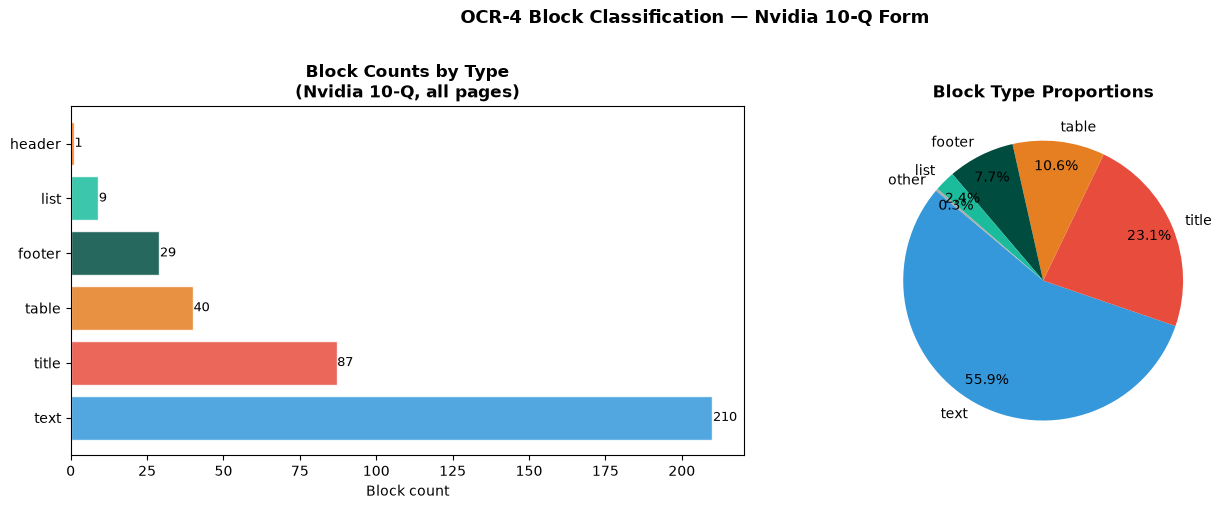

In [20]:
# ── 5b. Block-type distribution: bar + pie ────────────────────────────────────

type_counts = df_all['type'].value_counts()
colors      = [BLOCK_COLORS.get(t, '#888888') for t in type_counts.index]

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = ax_bar.barh(type_counts.index, type_counts.values,
                    color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, type_counts.values):
    ax_bar.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=9)
ax_bar.set_xlabel('Block count')
ax_bar.set_title('Block Counts by Type\n(Nvidia 10-Q, all pages)', fontweight='bold')

# Pie chart
threshold = 0.02 * type_counts.sum()
major     = type_counts[type_counts >= threshold].copy()
minor_sum = int(type_counts[type_counts < threshold].sum())
if minor_sum > 0:
    major = pd.concat([major, pd.Series([minor_sum], index=['other'])])
pie_labels = list(major.index)
pie_colors = [BLOCK_COLORS.get(lbl, '#AAAAAA') for lbl in pie_labels]
ax_pie.pie(major.values, labels=pie_labels, colors=pie_colors,
           autopct='%1.1f%%', startangle=140, pctdistance=0.82)
ax_pie.set_title('Block Type Proportions', fontweight='bold')

plt.suptitle('OCR-4 Block Classification — Nvidia 10-Q Form',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

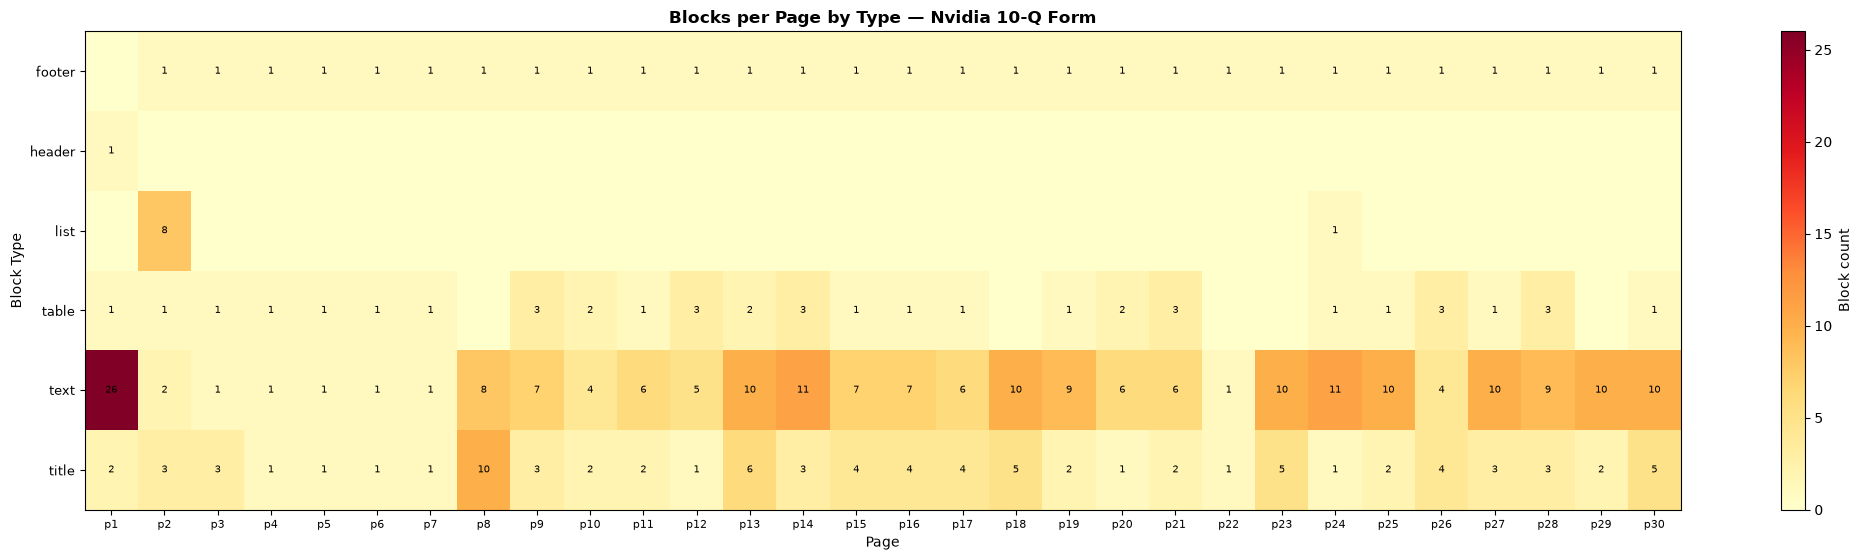

In [21]:
# ── 5c. Block-type heat-map: type × page ─────────────────────────────────────

pivot = (
    df_all.groupby(['type', 'page'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(1, n_pages + 1), fill_value=0)
)

fig, ax = plt.subplots(figsize=(max(10, n_pages * 0.7), len(pivot) * 0.7 + 1.5))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(n_pages))
ax.set_xticklabels([f'p{i}' for i in range(1, n_pages + 1)], fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xlabel('Page')
ax.set_ylabel('Block Type')
ax.set_title('Blocks per Page by Type — Nvidia 10-Q Form', fontsize=12, fontweight='bold')

for i in range(len(pivot.index)):
    for j in range(n_pages):
        val = pivot.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=7, color='black')

plt.colorbar(im, ax=ax, label='Block count')
plt.tight_layout()
plt.show()

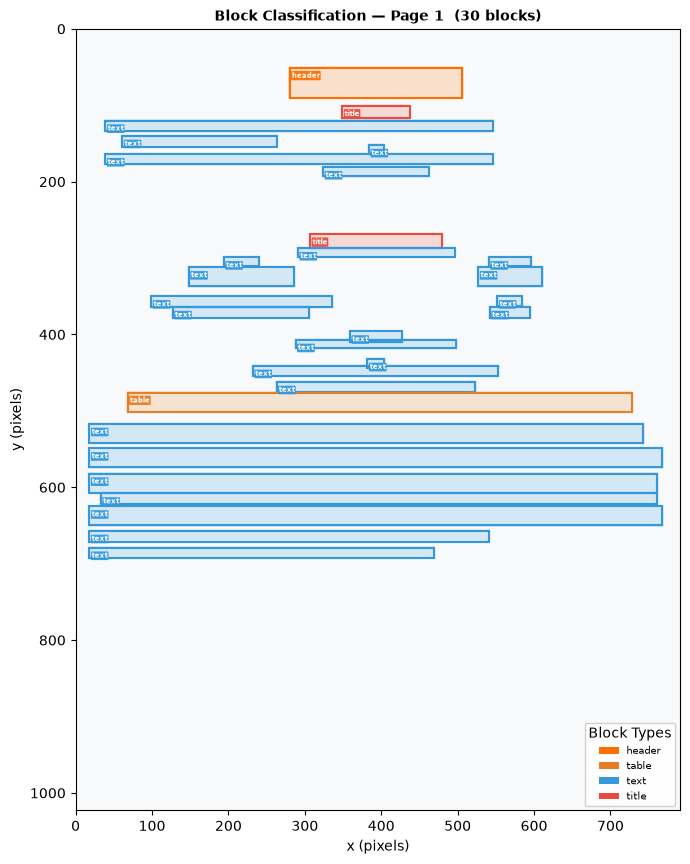

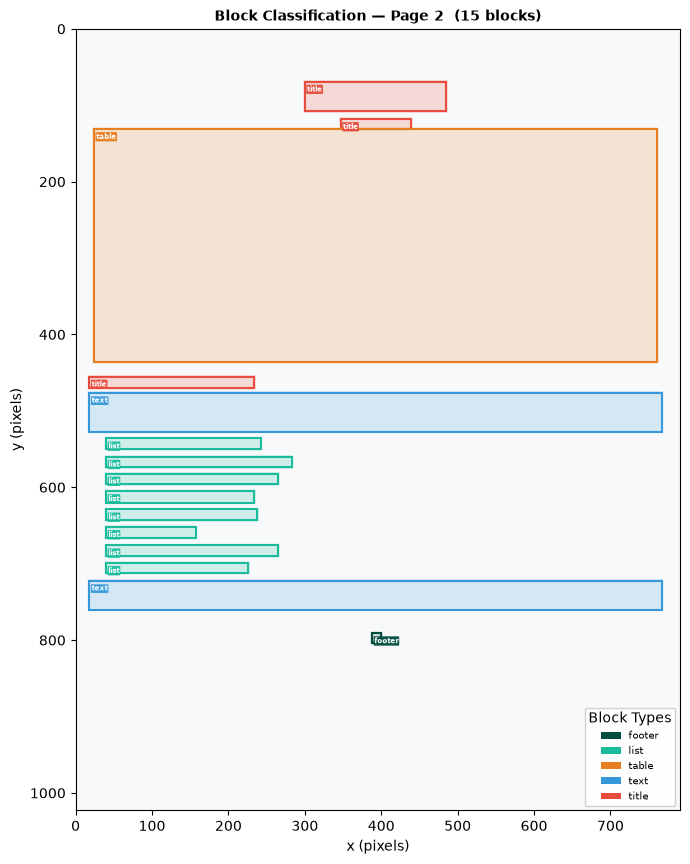

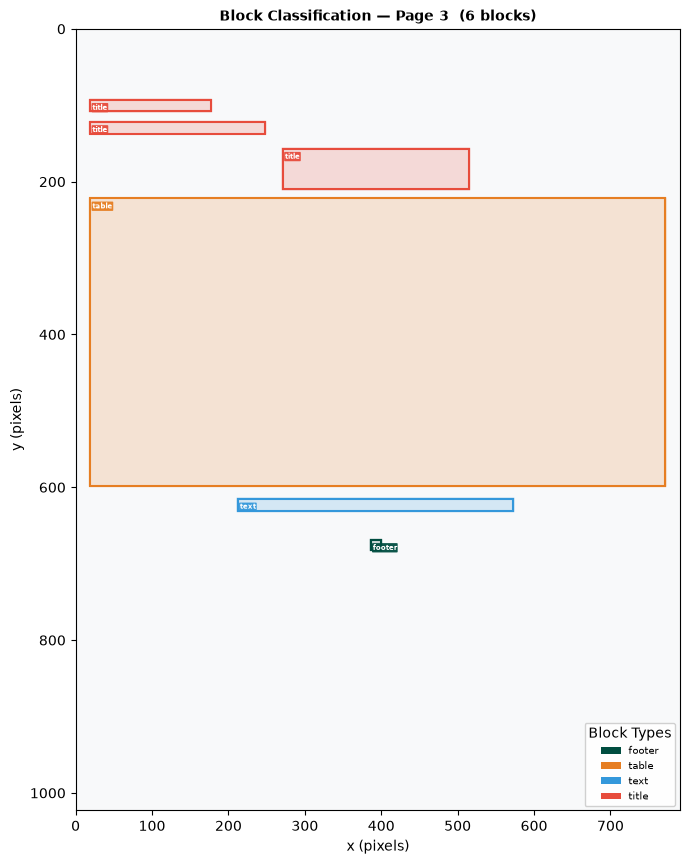

In [22]:
# ── 5d. Full block classification overlay on first three pages ───────────────

def render_all_blocks(page_data: dict, title: str = '') -> None:
    """Render ALL block types (including tables, images, headers) on one canvas."""
    dims   = page_data.get('dimensions') or {}
    width  = dims.get('width',  612)
    height = dims.get('height', 792)
    blocks = page_data.get('blocks') or []

    fig, ax = plt.subplots(figsize=(7, 10))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_facecolor('#F8F9FA')
    ax.set_aspect('equal')

    seen_types = set()
    for b in blocks:
        x1, y1 = b['top_left_x'], b['top_left_y']
        x2, y2 = b['bottom_right_x'], b['bottom_right_y']
        btype  = b['type']
        color  = BLOCK_COLORS.get(btype, '#888888')
        w, h   = x2 - x1, y2 - y1

        ax.add_patch(patches.FancyBboxPatch(
            (x1, y1), w, h,
            boxstyle='round,pad=2',
            linewidth=0, facecolor=color, alpha=0.18,
        ))
        ax.add_patch(patches.Rectangle(
            (x1, y1), w, h,
            linewidth=1.5, edgecolor=color, facecolor='none'
        ))
        ax.text(
            x1 + 3, y1 + 13, btype,
            fontsize=5, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.12', facecolor=color,
                      alpha=0.95, edgecolor='none'),
        )
        seen_types.add(btype)

    legend_handles = [
        patches.Patch(facecolor=BLOCK_COLORS.get(t, '#888'), label=t)
        for t in sorted(seen_types)
    ]
    ax.legend(handles=legend_handles, loc='lower right',
              fontsize=7, framealpha=0.9, title='Block Types')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
    plt.tight_layout()
    plt.show()


for page_obj in pages[:3]:
    pg_num = page_obj['index'] + 1
    n_blk  = len(page_obj.get('blocks') or [])
    render_all_blocks(
        page_obj,
        title=f'Block Classification — Page {pg_num}  ({n_blk} blocks)',
    )

In [23]:
# ── 5e. One example per detected block type ──────────────────────────────────

print('Block Classification Examples — Nvidia 10-Q')
print('=' * 72)
for btype in df_all['type'].unique():
    row     = df_all[df_all['type'] == btype].iloc[0]
    # look up raw content from pages
    page_blocks = pages[row['page'] - 1].get('blocks') or []
    match = next(
        (b for b in page_blocks
         if b['type'] == btype
         and b['top_left_x'] == row['x1']
         and b['top_left_y'] == row['y1']),
        None
    )
    content = match['content'][:120].replace('\n', ' ') if match else '(n/a)'
    count   = (df_all['type'] == btype).sum()
    print(f'\n  TYPE : {btype.upper():12s}  ({count} across doc)')
    print(f'  PAGE : {row["page"]}')
    print(f'  BBOX : ({row["x1"]}, {row["y1"]}) → ({row["x2"]}, {row["y2"]})  '
          f'[{row["width_px"]}×{row["height_px"]}px]')
    print(f'  TEXT : {content}{"…" if len(content) == 120 else ""}')
    print('-' * 72)

Block Classification Examples — Nvidia 10-Q

  TYPE : HEADER        (1 across doc)
  PAGE : 1
  BBOX : (280, 51) → (506, 90)  [226×39px]
  TEXT : UNITED STATES SECURITIES AND EXCHANGE COMMISSION Washington, D.C. 20549
------------------------------------------------------------------------

  TYPE : TITLE         (87 across doc)
  PAGE : 1
  BBOX : (349, 101) → (437, 117)  [88×16px]
  TEXT : # FORM 10-Q
------------------------------------------------------------------------

  TYPE : TEXT          (210 across doc)
  PAGE : 1
  BBOX : (39, 120) → (546, 134)  [507×14px]
  TEXT : ☒ QUARTERLY REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934
------------------------------------------------------------------------

  TYPE : TABLE         (40 across doc)
  PAGE : 1
  BBOX : (68, 476) → (728, 501)  [660×25px]
  TEXT : |  Title of each class | Trading Symbol(s) | Name of each exchange on which registered  | | --- | --- | --- | |  Common …
--------------------------

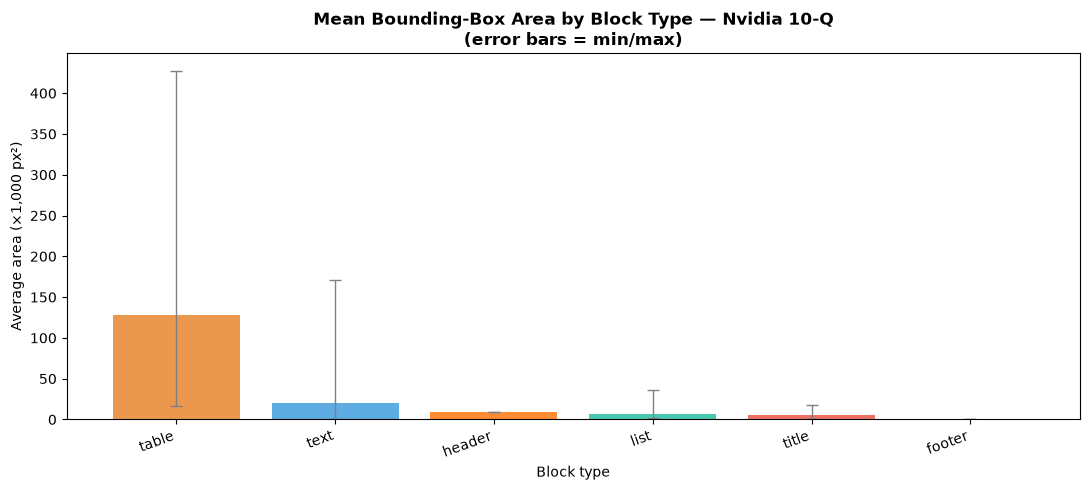

,avg_area,med_area,min_area,max_area,n
type,,,,,
table,"128,253","100,299","16,500","427,458",40
text,"20,606","19,834",228,"171,521",210
header,"8,814","8,814","8,814","8,814",1
list,"6,519","2,910","1,638","36,400",9
title,"5,281","3,090",663,"17,331",87
footer,210,208,144,294,29


In [24]:
# ── 5f. Average bounding-box area per block type ─────────────────────────────

area_stats = (
    df_all.groupby('type')['area_px2']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .sort_values('mean', ascending=False)
    .rename(columns={'mean': 'avg_area', 'median': 'med_area',
                     'min': 'min_area', 'max': 'max_area', 'count': 'n'})
)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [BLOCK_COLORS.get(t, '#888888') for t in area_stats.index]
x_pos  = np.arange(len(area_stats))
ax.bar(x_pos, area_stats['avg_area'] / 1_000, color=colors, alpha=0.8)
ax.errorbar(
    x=x_pos,
    y=area_stats['avg_area'].to_numpy() / 1_000,
    yerr=[
        (area_stats['avg_area'] - area_stats['min_area']).to_numpy() / 1_000,
        (area_stats['max_area'] - area_stats['avg_area']).to_numpy() / 1_000,
    ],
    fmt='none', color='gray', capsize=4, linewidth=1,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(area_stats.index, rotation=20, ha='right')
ax.set_ylabel('Average area (×1,000 px²)')
ax.set_xlabel('Block type')
ax.set_title('Mean Bounding-Box Area by Block Type — Nvidia 10-Q\n(error bars = min/max)',
             fontweight='bold')
plt.tight_layout()
plt.show()

display(area_stats.style.format({
    'avg_area': '{:,.0f}',
    'med_area': '{:,.0f}',
    'min_area': '{:,.0f}',
    'max_area': '{:,.0f}',
}))

---
## 6. Summary

In [25]:
# ── 6. Final summary dashboard ────────────────────────────────────────────────

avg_conf    = valid['avg'].mean() if len(valid) else float('nan')
min_conf    = valid['minimum'].min() if len(valid) else float('nan')
n_para_blk  = len(df_para)
n_all_blk   = len(df_all)
types_found = sorted(df_all['type'].unique())

summary_md = f"""
### OCR-4 Results — Nvidia 10-Q Form

| Metric | Value |
|--------|-------|
| Pages processed | {n_pages} |
| Total markdown chars | {df_md['Chars'].sum():,} |
| Paragraph-level blocks | {n_para_blk} ({', '.join(sorted(PARAGRAPH_TYPES & set(types_found)))}) |
| All block types detected | {len(types_found)}: {', '.join(f'`{t}`' for t in types_found)} |
| Total blocks (all types) | {n_all_blk} |
| Doc avg confidence | {avg_conf:.4f} |
| Doc min confidence | {min_conf:.4f} |
| Pages ≥ 0.90 confidence | {(valid['avg'] >= 0.90).sum()} / {len(valid)} |
"""

display(Markdown(summary_md))


### OCR-4 Results — Nvidia 10-Q Form

| Metric | Value |
|--------|-------|
| Pages processed | 30 |
| Total markdown chars | 67,088 |
| Paragraph-level blocks | 306 (list, text, title) |
| All block types detected | 6: `footer`, `header`, `list`, `table`, `text`, `title` |
| Total blocks (all types) | 376 |
| Doc avg confidence | 0.9873 |
| Doc min confidence | 0.2225 |
| Pages ≥ 0.90 confidence | 30 / 30 |
